# Loading Visium HD Data with Starfysh

**Azizi Lab** — Siyu He, Yinuo Jin, Lingting Shi

This notebook demonstrates how to load **10x Visium HD** spatial transcriptomics data directly from the unmodified Space Ranger HD output directory (no file restructuring needed), perform standard QC & preprocessing, and prepare the data for downstream Starfysh analysis.

---

## Visium HD output structure

Space Ranger HD writes outputs under an `outs/` subdirectory. The key files used here are:

```
{base_path}/
  └── {sample_id}/
        └── outs/
              ├── binned_outputs/
              │     ├── square_002um/   ← 2 µm bins (highest resolution)
              │     ├── square_008um/   ← 8 µm bins
              │     └── square_016um/   ← 16 µm bins (used by default)
              │           ├── filtered_feature_bc_matrix.h5
              │           └── spatial/
              │                 ├── tissue_positions.parquet
              │                 └── scalefactors_json.json
              └── spatial/
                    └── tissue_hires_image.png
```

## 1. Imports & configuration

In [10]:
import os
import json
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# ── plot defaults ─────────────────────────────────────────────────────────
font_list = set()
for fpath in matplotlib.font_manager.findSystemFonts():
    try:
        font_list.add(matplotlib.font_manager.get_font(fpath).family_name)
    except RuntimeError:
        pass
plot_font = 'Helvetica' if 'Helvetica' in font_list else 'FreeSans'
rcParams['font.family'] = plot_font
rcParams.update({'font.size': 10, 'figure.dpi': 150, 'figure.figsize': (4, 4)})


## 2. Paths

Set `HD_BASE_PATH` to the folder that contains your Visium HD sample directories. Each sample directory should contain an `outs/` subfolder as produced by Space Ranger HD.

In [11]:
from pathlib import Path

HD_BASE_PATH = Path('/Users/lingting/Documents/GVHD_project_v2/VisiumHD')

# per-sample minimum count thresholds (adjust as needed)
MIN_COUNTS = {
    'SLV11': 150,
    'SLV12': 50,
    'SLV13': 50,
    'SLV14': 50,
    'SLV15': 50,
    'SLV16': 150,
    'SLV17': 50,
    'SLV18': 150,
}


## 3. Loader function

`load_visium_hd_data` reads a single Visium HD sample from its native Space Ranger HD directory layout and returns:

| Variable | Contents |
|---|---|
| `adata_raw` | Raw count matrix, spatial coords in `.obs`, HVG flag in `.var` |
| `adata_norm` | Log-normalised, MT/RB-filtered, highly variable genes selected |
| `img_metadata` | Dict with `img` (H&E array), `map_info` (DataFrame), `scalefactor` (JSON) |

The `bin_size` parameter selects the spatial resolution:
- `'square_002um'` — 2 µm bins (highest resolution, largest file)
- `'square_008um'` — 8 µm bins
- `'square_016um'` — 16 µm bins (default, recommended starting point)


In [12]:
def load_visium_hd_data(
        base_path, sample_id,
        bin_size='square_016um',
        min_counts=50,
        n_top_genes=2000,
        mt_thld=20
):
    """
    Load a single Visium HD sample from unmodified Space Ranger HD output.

    Parameters
    ----------
    base_path : str or Path
        Directory that contains sample sub-folders.
    sample_id : str
        Name of the sample sub-folder (e.g. 'SLV18').
    bin_size : str
        Bin resolution: 'square_002um', 'square_008um', or 'square_016um'.
    min_counts : int
        Minimum total UMI counts to retain a barcode.
    n_top_genes : int
        Number of highly variable genes to select.
    mt_thld : float
        Maximum allowed % mitochondrial counts.

    Returns
    -------
    (adata_raw, adata_norm, img_metadata)
    """
    outs = os.path.join(base_path, sample_id, 'outs')
    bin_dir = os.path.join(outs, 'binned_outputs', bin_size)

    # ── 1. Read spatial positions ──────────────────────────────────────────
    tissue_positions = pd.read_parquet(
        os.path.join(bin_dir, 'spatial', 'tissue_positions.parquet')
    )

    # ── 2. Read gene-expression matrix ─────────────────────────────────────
    adata = sc.read_10x_h5(
        os.path.join(bin_dir, 'filtered_feature_bc_matrix.h5')
    )

    # ── 3. Attach spatial coordinates ──────────────────────────────────────
    matched = tissue_positions[tissue_positions['barcode'].isin(adata.obs.index)]
    matched = matched.set_index('barcode').loc[adata.obs.index]
    coord_cols = ['in_tissue', 'array_row', 'array_col',
                  'pxl_row_in_fullres', 'pxl_col_in_fullres']
    adata.obs[coord_cols] = matched[coord_cols]
    adata.var_names_make_unique()
    adata.obs['sample'] = sample_id

    if '_index' in adata.var.columns:
        adata.var_names = adata.var['_index']
        adata.var_names.name = 'Genes'
        adata.var.drop('_index', axis=1, inplace=True)

    # ── 4. QC metrics & basic cell filter ──────────────────────────────────
    adata.var['mt'] = adata.var_names.str.startswith('MT-')
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)
    sc.pp.filter_cells(adata, min_counts=min_counts)

    adata_raw = adata.copy()

    # ── 5. MT / ribosomal gene filtering ───────────────────────────────────
    adata.var['mt'] = (
        adata.var_names.str.startswith('MT-') |
        adata.var_names.str.startswith('mt-')
    )
    adata.var['rb'] = (
        adata.var_names.str.startswith('RP-') |
        adata.var_names.str.startswith('rp-')
    )
    sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)
    mask_cell = adata.obs['pct_counts_mt'] < mt_thld
    mask_gene = ~adata.var['mt'] & ~adata.var['rb']
    adata = adata[mask_cell, mask_gene]

    # ── 6. Normalise & select highly variable genes ────────────────────────
    sc.pp.normalize_total(adata, inplace=True)
    sc.pp.log1p(adata)
    sc.pp.highly_variable_genes(adata, flavor='seurat',
                                n_top_genes=n_top_genes, inplace=True)

    # Align raw to the filtered obs / var
    adata_raw = adata_raw[adata.obs_names, adata.var_names]
    adata_raw.var['highly_variable'] = adata.var['highly_variable']
    adata_raw.obs = adata.obs

    # ── 7. Image metadata ──────────────────────────────────────────────────
    with open(os.path.join(bin_dir, 'spatial', 'scalefactors_json.json')) as f:
        scalefactor = json.load(f)

    img = plt.imread(os.path.join(outs, 'spatial', 'tissue_hires_image.png'))

    map_info = matched[['in_tissue', 'array_row', 'array_col',
                         'pxl_row_in_fullres', 'pxl_col_in_fullres']].copy()
    map_info['imagerow'] = (
        pd.to_numeric(map_info['pxl_row_in_fullres'], errors='coerce')
        .fillna(0).astype(int)
    )
    map_info['imagecol'] = (
        pd.to_numeric(map_info['pxl_col_in_fullres'], errors='coerce')
        .fillna(0).astype(int)
    )
    map_info = map_info[['array_row', 'array_col', 'imagerow', 'imagecol']]

    img_metadata = {'img': img, 'map_info': map_info, 'scalefactor': scalefactor}

    return adata_raw, adata, img_metadata


## 4. Load a single sample (SLV18)

Load SLV18 at the default 16 µm bin resolution.

In [13]:
adata_raw, adata_norm, img_metadata = load_visium_hd_data(
    HD_BASE_PATH,
    sample_id='SLV18',
    bin_size='square_016um',
    min_counts=MIN_COUNTS.get('SLV18', 50),
    n_top_genes=2000,
    mt_thld=20,
)

print('Raw AnnData:')
print(adata_raw)
print('\nNormalised AnnData:')
print(adata_norm)


Raw AnnData:
AnnData object with n_obs × n_vars = 26065 × 18074
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable'

Normalised AnnData:
AnnData object with n_obs × n_vars = 26065 × 18074
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_coun

### 4a. Inspect spatial metadata

Each barcode carries its tissue coordinates in `.obs`.

In [14]:
adata_norm.obs[['array_row', 'array_col',
               'pxl_row_in_fullres', 'pxl_col_in_fullres',
               'pct_counts_mt', 'total_counts']].head()


,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres,pct_counts_mt,total_counts
s_016um_00230_00364-1,230,364,4145.607089,1563.059203,2.544529,393.0
s_016um_00329_00125-1,329,125,5835.279554,5796.558629,9.254808,832.0
s_016um_00280_00313-1,280,313,5014.937217,2473.386297,18.261826,909.0
s_016um_00184_00346-1,184,346,3330.959685,1869.037823,3.244838,339.0
s_016um_00343_00189-1,343,189,6096.618267,4672.648141,0.922131,976.0


### 4b. QC plots

Violin plots of total counts, genes detected, and % mitochondrial reads.

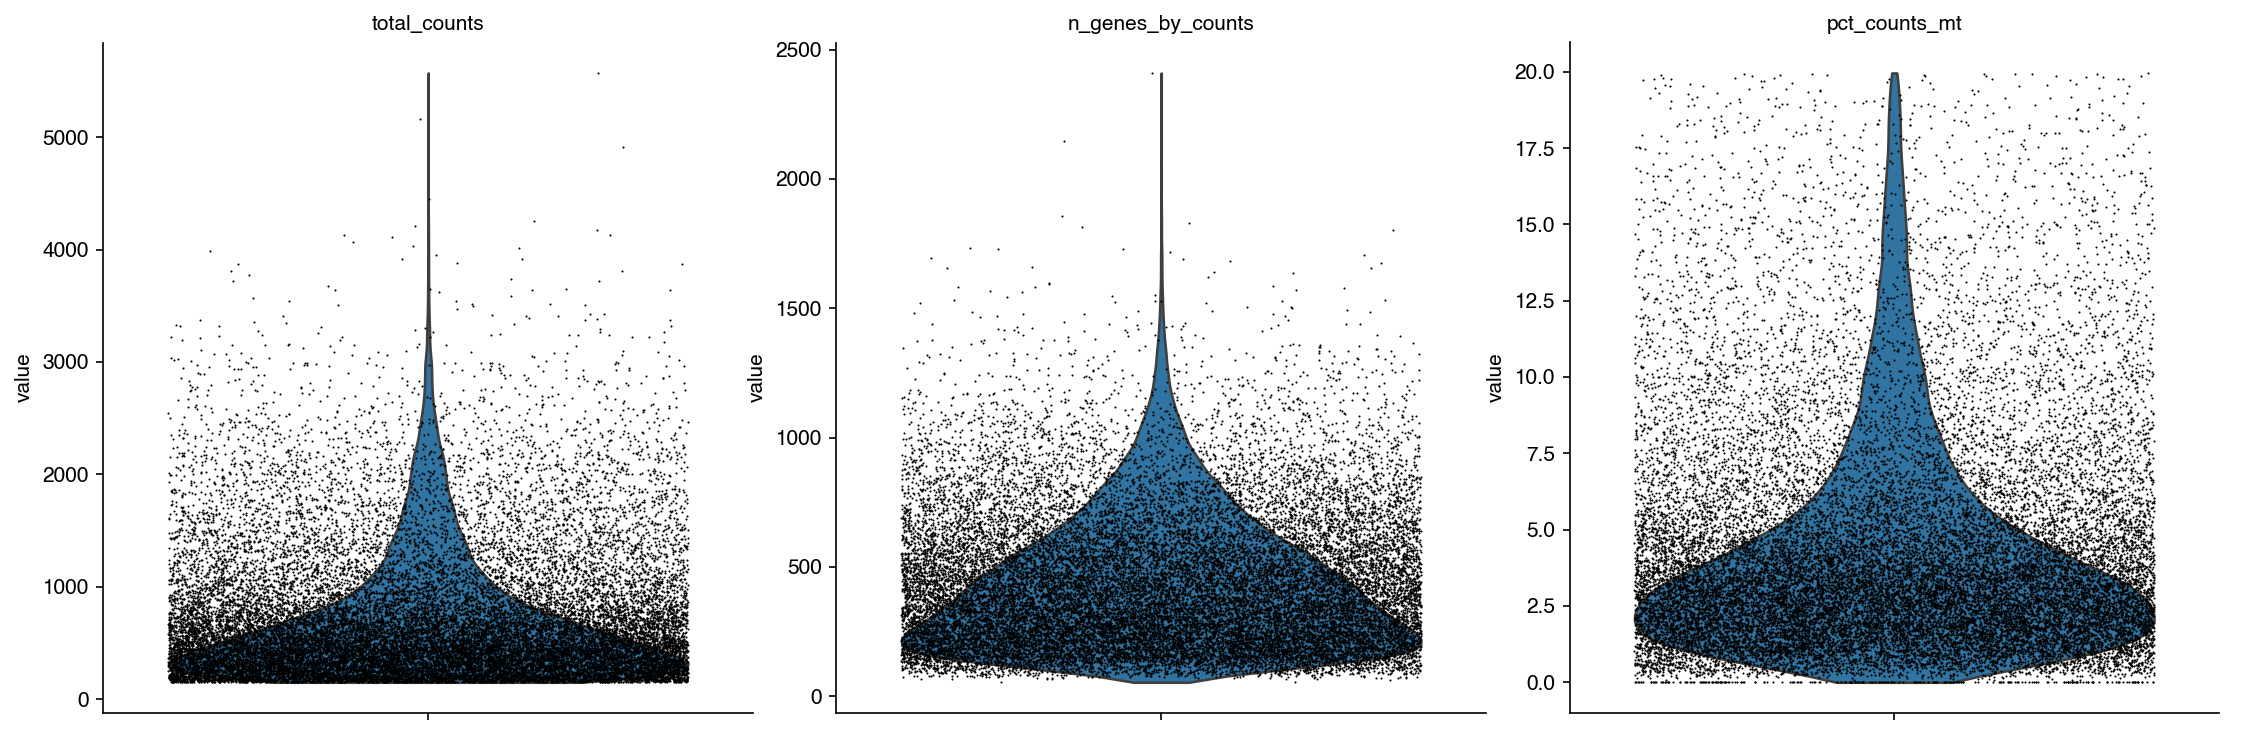

In [15]:
sc.pl.violin(
    adata_norm,
    ['total_counts', 'n_genes_by_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
)


### 4c. Spatial distribution of total counts

Quick sanity check: plot spots coloured by library size over the tissue footprint.

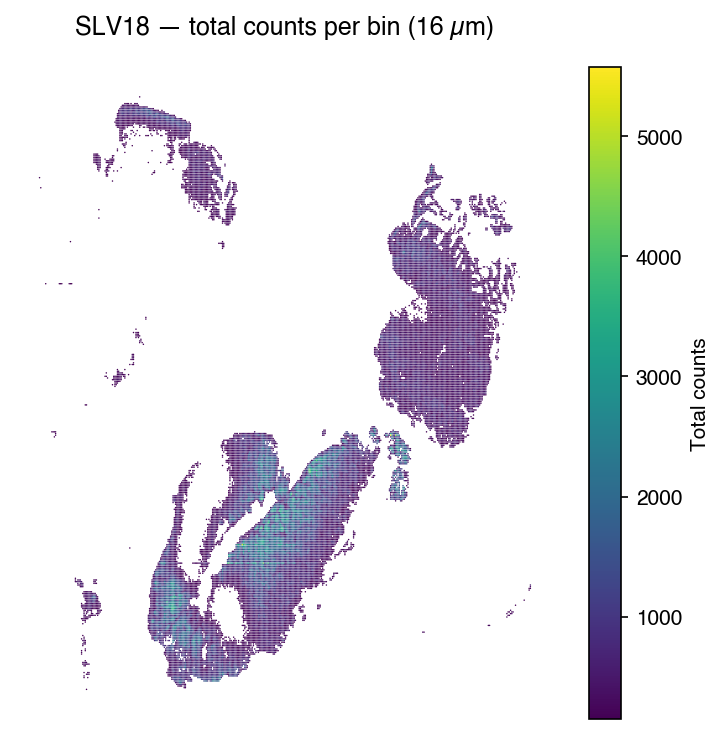

In [16]:
fig, ax = plt.subplots(figsize=(5, 5))
sc_df = adata_norm.obs[['array_row', 'array_col', 'total_counts']].copy()
scatter_pts = ax.scatter(
    sc_df['array_col'], -sc_df['array_row'],   # flip row so tissue is upright
    c=sc_df['total_counts'],
    s=0.5, cmap='viridis', linewidths=0,
)
plt.colorbar(scatter_pts, ax=ax, label='Total counts')
ax.set_title('SLV18 — total counts per bin (16 µm)')
ax.axis('off')
plt.tight_layout()
plt.show()


### 4d. H&E tissue image

Show the high-resolution H&E image stored in `img_metadata['img']`.

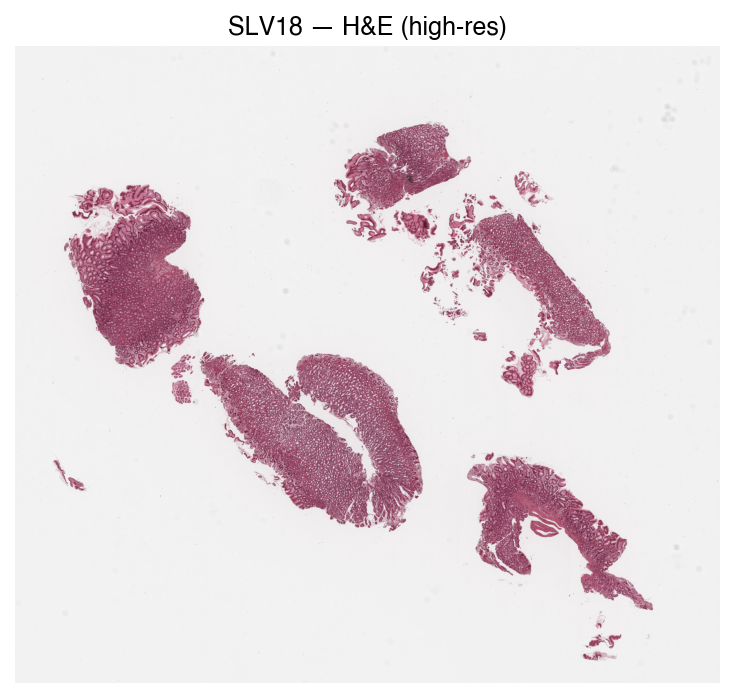

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(img_metadata['img'])
ax.set_title('SLV18 — H&E (high-res)')
ax.axis('off')
plt.tight_layout()
plt.show()


### 4e. Highly variable genes

Visualise dispersion vs. mean for the selected HVGs.

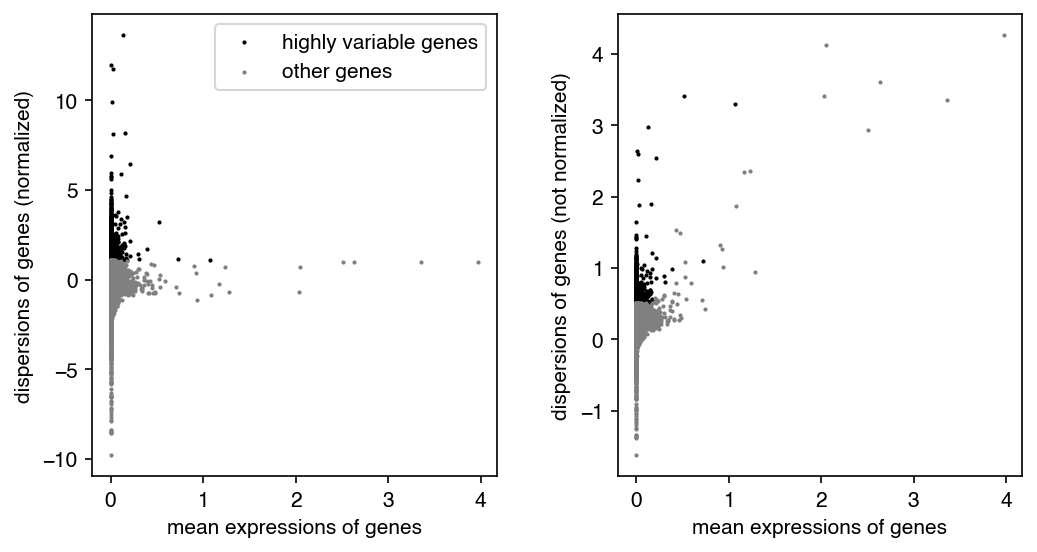

In [18]:
sc.pl.highly_variable_genes(adata_norm)


## 5. Load multiple samples

Iterate over a sample list, load each with `load_visium_hd_data`, annotate `.obs` with clinical metadata, then concatenate.

In [19]:
meta_info = pd.DataFrame([
    ['SLV18', 'C162', 'Stomach', 'Mild'],
    # add further rows as needed, e.g.:
    # ['SLV17', 'ND001', 'Ascending_Colon', 'ND'],
], columns=['sample', 'patient', 'tissue_type', 'grade'])

adata_raw_all   = []
adata_norm_all  = []
img_metadata_all = {}

for _, row in meta_info.iterrows():
    sid = row['sample']
    print(f'Loading {sid} ...')

    a_raw, a_norm, img_meta = load_visium_hd_data(
        HD_BASE_PATH, sid,
        min_counts=MIN_COUNTS.get(sid, 50),
        n_top_genes=2000,
        mt_thld=20,
    )

    # annotate clinical metadata
    for col in ['patient', 'tissue_type', 'grade']:
        a_raw.obs[col]  = row[col]
        a_norm.obs[col] = row[col]

    # make barcode names globally unique
    a_raw.obs_names  = a_raw.obs_names  + '-' + sid
    a_norm.obs_names = a_norm.obs_names + '-' + sid

    img_meta['map_info'].index = img_meta['map_info'].index + '-' + sid
    img_meta['map_info'] = img_meta['map_info'][
        img_meta['map_info'].index.isin(a_raw.obs_names)
    ]

    adata_raw_all.append(a_raw)
    adata_norm_all.append(a_norm)
    img_metadata_all[sid] = img_meta

adata_concat      = anndata.concat(adata_raw_all)
adata_norm_concat = anndata.concat(adata_norm_all)

# re-compute HVGs on the joint dataset
sc.pp.highly_variable_genes(adata_norm_concat)
adata_concat.uns = adata_norm_concat.uns
adata_concat.var = adata_norm_concat.var

print('Concatenated raw:  ', adata_concat)
print('Concatenated norm: ', adata_norm_concat)


Loading SLV18 ...
Concatenated raw:   AnnData object with n_obs × n_vars = 26065 × 18074
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'patient', 'tissue_type', 'grade'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'hvg'
Concatenated norm:  AnnData object with n_obs × n_vars = 26065 × 18074
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p

## 6. Save processed data

Write the concatenated objects to `.h5ad` for downstream Starfysh analysis.

In [20]:
OUTPUT_DIR = HD_BASE_PATH   # change to a dedicated output folder if preferred

adata_concat.write(OUTPUT_DIR / 'adata_hd_raw.h5ad')
adata_norm_concat.write(OUTPUT_DIR / 'adata_hd_norm.h5ad')
print('Saved to', OUTPUT_DIR)


Saved to /Users/lingting/Documents/GVHD_project_v2/VisiumHD


## 7. Next steps

The objects produced here are ready for the full Starfysh integration pipeline:

1. Load a cell-type signature gene list (`gene_sig` CSV).
2. Build per-sample `VisiumArguments` objects.
3. Construct `VisiumArguments_integrate` for joint analysis.
4. Train Starfysh (`utils_integrate.run_starfysh`).
5. Visualise deconvolution scores and spatial hubs.

See `Starfysh_tutorial_integration_all_with_no_arch_with_figures.ipynb` for the full pipeline.